<a href="https://colab.research.google.com/github/zilzaniabdullahi1992-max/darul-hikma-school.vercel.app/blob/main/02_llm_ATF26_659079_NGA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1.2: LLM Big Picture & Anatomy for Digital Twins

## Learning Objectives
- Understand the overall architecture of LLMs
- Learn about tokens, tokenization, and embeddings
- See how different components work together
- Apply these concepts to building a language-enabled digital twin

## Key Insight
> "Know the different bits of the LLM architecture and how they work together to generate outputs."

## Digital Twin Context
Today we'll enhance our digital twin with language understanding capabilities. By the end, your digital twin will:
- Convert text to numerical representations
- Understand word relationships and context
- Process sequences of information

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import re

# Set style
sns.set_style('whitegrid')
np.random.seed(42)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


---
## Part 1: Tokenization - Breaking Text into Pieces

Before an LLM can process text, it needs to convert words into tokens.

### 1.1 Simple Word Tokenization

In [2]:
def simple_tokenize(text):
    """
    Basic tokenization: split text into words.

    Args:
        text: Input string

    Returns:
        list: Tokens
    """
    # Convert to lowercase and split
    text = text.lower()
    # Remove punctuation and split
    tokens = re.findall(r'\b\w+\b', text)
    return tokens

# Example: Digital twin's user description
user_description = """
I love running in the morning before work. Coffee is essential.
I enjoy reading science fiction and coding in Python.
Weekends are for family time and outdoor activities.
"""

tokens = simple_tokenize(user_description)
print("Original text:")
print(user_description)
print(f"\nTokens ({len(tokens)} total):")
print(tokens[:20], "...")  # Show first 20

# Count token frequencies
token_counts = Counter(tokens)
print("\nMost common tokens:")
for token, count in token_counts.most_common(10):
    print(f"  {token}: {count}")

Original text:

I love running in the morning before work. Coffee is essential.
I enjoy reading science fiction and coding in Python.
Weekends are for family time and outdoor activities.


Tokens (28 total):
['i', 'love', 'running', 'in', 'the', 'morning', 'before', 'work', 'coffee', 'is', 'essential', 'i', 'enjoy', 'reading', 'science', 'fiction', 'and', 'coding', 'in', 'python'] ...

Most common tokens:
  i: 2
  in: 2
  and: 2
  love: 1
  running: 1
  the: 1
  morning: 1
  before: 1
  work: 1
  coffee: 1


### 🎯 Exercise 1.1 (Easy): Personal Tokenization

**Task**: Write a short description of yourself (3-4 sentences) and tokenize it.

**Questions**:
1. How many unique tokens do you have?
2. What are your most frequent tokens?
3. How does tokenization help the digital twin understand you?

In [3]:
import re
from collections import Counter

def simple_tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())

my_description = """
I am Abdullahi Zilzani, an Education Officer and Examination Officer at Lugu Marina Primary School in Tsafe, Zamfara State, Nigeria. I hold a B.Sc. in Computer Science and I am pursuing an M.Sc. in Artificial Intelligence at Ahmadu Bello University, Zaria. I build software, including school management systems and a mobile food delivery app. I also run a livestock business, and I speak English and Hausa.
"""

my_tokens = simple_tokenize(my_description)
print(f"Total tokens: {len(my_tokens)}")
print(f"Unique tokens: {len(set(my_tokens))}")

freq = Counter(my_tokens)
print("Most frequent:", freq.most_common(5))
print("Type-token ratio:", round(len(set(my_tokens)) / len(my_tokens), 2))

Total tokens: 68
Unique tokens: 49
Most frequent: [('i', 6), ('and', 5), ('in', 3), ('a', 3), ('am', 2)]
Type-token ratio: 0.72


### 1.2 Subword Tokenization (BPE-like)

Real LLMs use subword tokenization to handle rare words and morphology.

In [6]:
class SimpleTokenizer:
    """Simple subword tokenizer inspired by BPE."""

    def __init__(self, vocab_size=100):
        self.vocab_size = vocab_size
        self.word_to_id = {}
        self.id_to_word = {}
        self.subword_vocab = []

    def build_vocab(self, texts):
        """
        Build vocabulary from texts.

        Args:
            texts: List of text strings
        """
        # Get all words
        all_words = []
        for text in texts:
            all_words.extend(simple_tokenize(text))

        # Count frequencies
        word_counts = Counter(all_words)

        # Take most common words
        most_common = word_counts.most_common(self.vocab_size)

        # Build vocabulary
        special_tokens = ['<PAD>', '<UNK>', '<START>', '<END>']
        self.word_to_id = {word: i for i, word in enumerate(special_tokens)}

        for i, (word, count) in enumerate(most_common):
            self.word_to_id[word] = i + len(special_tokens)

        self.id_to_word = {i: word for word, i in self.word_to_id.items()}

        print(f"Vocabulary built: {len(self.word_to_id)} tokens")

    def encode(self, text):
        """
        Convert text to token IDs.

        Args:
            text: Input string

        Returns:
            list: Token IDs
        """
        tokens = simple_tokenize(text)
        unk_id = self.word_to_id['<UNK>']
        return [self.word_to_id.get(token, unk_id) for token in tokens]

    def decode(self, token_ids):
        """
        Convert token IDs back to text.

        Args:
            token_ids: List of token IDs

        Returns:
            str: Decoded text
        """
        tokens = [self.id_to_word.get(id, '<UNK>') for id in token_ids]
        # Filter special tokens
        tokens = [t for t in tokens if not t.startswith('<')]
        return ' '.join(tokens)

# Build tokenizer for digital twin
training_texts = [
    user_description,
    "I prefer tea over coffee in the afternoon",
    "Running helps me stay focused and energized",
    "Python is my favorite programming language",
    "I love spending time with family on weekends",
]

tokenizer = SimpleTokenizer(vocab_size=50)
tokenizer.build_vocab(training_texts)

# Test encoding and decoding
test_text = "I love running and coding in Python"
encoded = tokenizer.encode(test_text)
decoded = tokenizer.decode(encoded)

print(f"\nOriginal: {test_text}")
print(f"Encoded: {encoded}")
print(f"Decoded: {decoded}")

Vocabulary built: 45 tokens

Original: I love running and coding in Python
Encoded: [4, 7, 8, 6, 24, 5, 12]
Decoded: i love running and coding in python


### 🎯 Exercise 1.2 (Intermediate): Vocabulary Analysis

**Task**: Analyze what happens with different vocabulary sizes.

**Questions**:
1. What happens when you use a very small vocabulary (vocab_size=10)?
2. How many unknown tokens do you get?
3. What's the trade-off between vocabulary size and coverage?

vocab=10   unknown=11/16 coverage=31%
vocab=20   unknown=8/16 coverage=50%
vocab=50   unknown=8/16 coverage=50%
vocab=100  unknown=3/16 coverage=81%


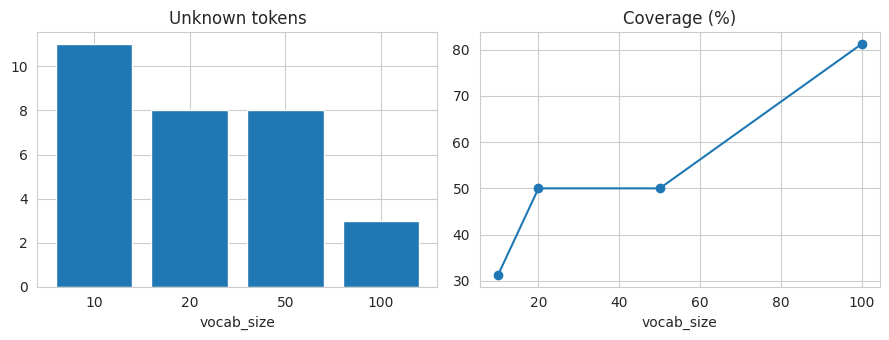

In [4]:
import re
from collections import Counter
import matplotlib.pyplot as plt

def simple_tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())

# Corpus used to build the vocabulary (your description + a few extra sentences)
corpus = """
I am Abdullahi Zilzani, an Education Officer and Examination Officer at Lugu Marina Primary School in Tsafe, Zamfara State, Nigeria.
I hold a B.Sc. in Computer Science and I am pursuing an M.Sc. in Artificial Intelligence at Ahmadu Bello University, Zaria.
I build software, including school management systems and a mobile food delivery app.
I also run a livestock business, and I speak English and Hausa.
I love teaching children and I love learning new things every day.
Programming is essential for building useful tools and I enjoy reading about machine learning.
The weekend is for family, rest and activities such as running and reading.
Coffee and tea are common, and good food is essential for a productive day.
"""

vocab_sizes = [10, 20, 50, 100]
test_texts = [
    "I love running and programming",
    "Coffee is essential for productivity",
    "Weekend activities include hiking and reading",
]

freq = Counter(simple_tokenize(corpus))

def build_vocab(size):
    # top (size - 1) words; one slot reserved for <UNK>
    return {w for w, _ in freq.most_common(size - 1)}

test_tokens = [t for s in test_texts for t in simple_tokenize(s)]

results = []
for size in vocab_sizes:
    vocab = build_vocab(size)
    unk = [t for t in test_tokens if t not in vocab]
    coverage = 1 - len(unk) / len(test_tokens)
    results.append((size, len(unk), coverage))
    print(f"vocab={size:<4} unknown={len(unk)}/{len(test_tokens)} coverage={coverage:.0%}")

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].bar([str(r[0]) for r in results], [r[1] for r in results])
ax[0].set_title("Unknown tokens"); ax[0].set_xlabel("vocab_size")
ax[1].plot([r[0] for r in results], [r[2] * 100 for r in results], marker="o")
ax[1].set_title("Coverage (%)"); ax[1].set_xlabel("vocab_size")
plt.tight_layout(); plt.show()

---
## Part 2: Embeddings - Giving Meaning to Tokens

Embeddings convert tokens into dense vectors that capture semantic meaning.

### 2.1 Creating Simple Embeddings

In [7]:
class SimpleEmbedding:
    """Simple word embedding layer."""

    def __init__(self, vocab_size, embedding_dim):
        """
        Initialize embedding matrix.

        Args:
            vocab_size: Size of vocabulary
            embedding_dim: Dimension of embedding vectors
        """
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        # Initialize with random values
        self.embeddings = np.random.randn(vocab_size, embedding_dim) * 0.1

    def embed(self, token_ids):
        """
        Get embeddings for token IDs.

        Args:
            token_ids: List of token IDs

        Returns:
            np.array: Embedding vectors
        """
        return self.embeddings[token_ids]

    def similarity(self, id1, id2):
        """
        Calculate cosine similarity between two tokens.

        Args:
            id1, id2: Token IDs

        Returns:
            float: Cosine similarity
        """
        vec1 = self.embeddings[id1]
        vec2 = self.embeddings[id2]

        # Cosine similarity
        dot_product = np.dot(vec1, vec2)
        norm1 = np.linalg.norm(vec1)
        norm2 = np.linalg.norm(vec2)

        return dot_product / (norm1 * norm2)

# Create embeddings for our vocabulary
vocab_size = len(tokenizer.word_to_id)
embedding_dim = 16  # Small dimension for visualization

embedding_layer = SimpleEmbedding(vocab_size, embedding_dim)

# Test with some words
test_words = ['running', 'coding', 'coffee', 'python', 'family']
print("Word embeddings:")
for word in test_words:
    if word in tokenizer.word_to_id:
        token_id = tokenizer.word_to_id[word]
        embedding = embedding_layer.embed([token_id])[0]
        print(f"\n{word} (ID: {token_id}):")
        print(f"  Embedding (first 5 dims): {embedding[:5]}")
        print(f"  Norm: {np.linalg.norm(embedding):.3f}")

Word embeddings:

running (ID: 8):
  Embedding (first 5 dims): [ 0.00996514 -0.05034757 -0.15506634  0.0068563  -0.10623037]
  Norm: 0.381

coding (ID: 24):
  Embedding (first 5 dims): [-0.07591327  0.01503938  0.0341756   0.18761708  0.09504238]
  Norm: 0.442

coffee (ID: 10):
  Embedding (first 5 dims): [-0.09746817  0.07870846  0.11585956 -0.08206823  0.09633761]
  Norm: 0.345

python (ID: 12):
  Embedding (first 5 dims): [ 0.02140937 -0.12457388  0.01731809  0.03853174 -0.08838574]
  Norm: 0.315

family (ID: 14):
  Embedding (first 5 dims): [-0.04719319  0.10889506  0.006428   -0.10777448 -0.07153037]
  Norm: 0.385


### 2.2 Training Embeddings with Context

Embeddings learn meaning from co-occurrence patterns (Word2Vec style).

In [8]:
def train_embeddings(tokenizer, texts, embedding_dim=16, window_size=2,
                     learning_rate=0.01, epochs=100):
    """
    Train embeddings using skip-gram approach.

    Args:
        tokenizer: Tokenizer instance
        texts: List of training texts
        embedding_dim: Dimension of embeddings
        window_size: Context window size
        learning_rate: Learning rate
        epochs: Number of training epochs

    Returns:
        SimpleEmbedding: Trained embedding layer
    """
    vocab_size = len(tokenizer.word_to_id)
    embeddings = SimpleEmbedding(vocab_size, embedding_dim)

    # Create training pairs (center word, context word)
    training_pairs = []
    for text in texts:
        token_ids = tokenizer.encode(text)
        for i, center_id in enumerate(token_ids):
            # Get context window
            start = max(0, i - window_size)
            end = min(len(token_ids), i + window_size + 1)
            context_ids = [token_ids[j] for j in range(start, end) if j != i]
            for context_id in context_ids:
                training_pairs.append((center_id, context_id))

    print(f"Training on {len(training_pairs)} word pairs...")

    # Simple training loop
    for epoch in range(epochs):
        total_loss = 0
        np.random.shuffle(training_pairs)

        for center_id, context_id in training_pairs:
            # Get embeddings
            center_emb = embeddings.embeddings[center_id]
            context_emb = embeddings.embeddings[context_id]

            # Calculate similarity
            similarity = np.dot(center_emb, context_emb)

            # Gradient descent (simplified)
            gradient = context_emb - similarity * center_emb
            embeddings.embeddings[center_id] += learning_rate * gradient

            total_loss += (1 - similarity) ** 2

        if epoch % 20 == 0:
            avg_loss = total_loss / len(training_pairs)
            print(f"Epoch {epoch}: Loss = {avg_loss:.4f}")

    return embeddings

# Train embeddings
trained_embeddings = train_embeddings(tokenizer, training_texts,
                                     embedding_dim=16, epochs=100)

print("\n✅ Embeddings trained!")

Training on 198 word pairs...
Epoch 0: Loss = 0.9954
Epoch 20: Loss = 0.7512
Epoch 40: Loss = 0.2963
Epoch 60: Loss = 0.0714
Epoch 80: Loss = 0.0170

✅ Embeddings trained!


In [9]:
# Test similarity after training
def find_similar_words(word, tokenizer, embeddings, top_k=5):
    """
    Find most similar words to given word.

    Args:
        word: Query word
        tokenizer: Tokenizer instance
        embeddings: Embedding layer
        top_k: Number of similar words to return

    Returns:
        list: Similar words with similarities
    """
    if word not in tokenizer.word_to_id:
        return None

    word_id = tokenizer.word_to_id[word]
    word_emb = embeddings.embeddings[word_id]

    # Calculate similarities with all words
    similarities = []
    for other_word, other_id in tokenizer.word_to_id.items():
        if other_word.startswith('<') or other_id == word_id:
            continue
        sim = embeddings.similarity(word_id, other_id)
        similarities.append((other_word, sim))

    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

# Test with some words
test_words = ['running', 'python', 'coffee', 'love']
for word in test_words:
    similar = find_similar_words(word, tokenizer, trained_embeddings)
    if similar:
        print(f"\nWords similar to '{word}':")
        for similar_word, sim in similar:
            print(f"  {similar_word}: {sim:.3f}")


Words similar to 'running':
  love: 0.977
  in: 0.974
  coding: 0.960
  the: 0.947
  i: 0.945

Words similar to 'python':
  in: 0.980
  love: 0.966
  coding: 0.963
  spending: 0.943
  running: 0.943

Words similar to 'coffee':
  work: 0.982
  is: 0.979
  over: 0.979
  the: 0.975
  before: 0.966

Words similar to 'love':
  spending: 0.978
  running: 0.977
  i: 0.976
  in: 0.974
  python: 0.966


### 🎯 Exercise 2.1 (Intermediate): Embedding Visualization

**Task**: Visualize word embeddings in 2D space using dimensionality reduction.

**Steps**:
1. Use PCA or t-SNE to reduce embeddings to 2D
2. Plot the words
3. Identify clusters of related words

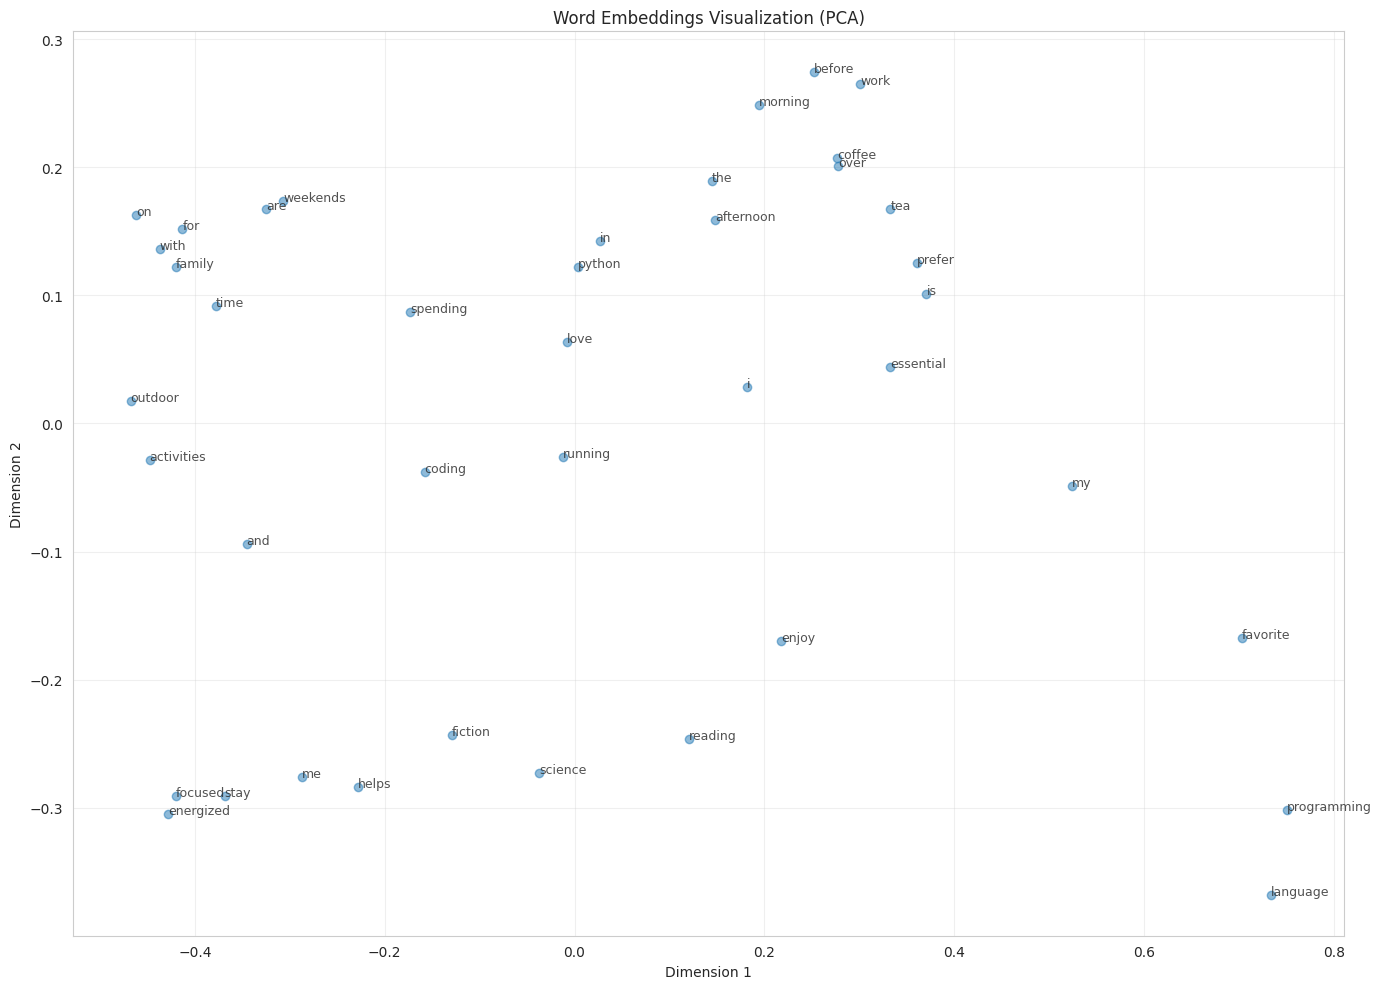

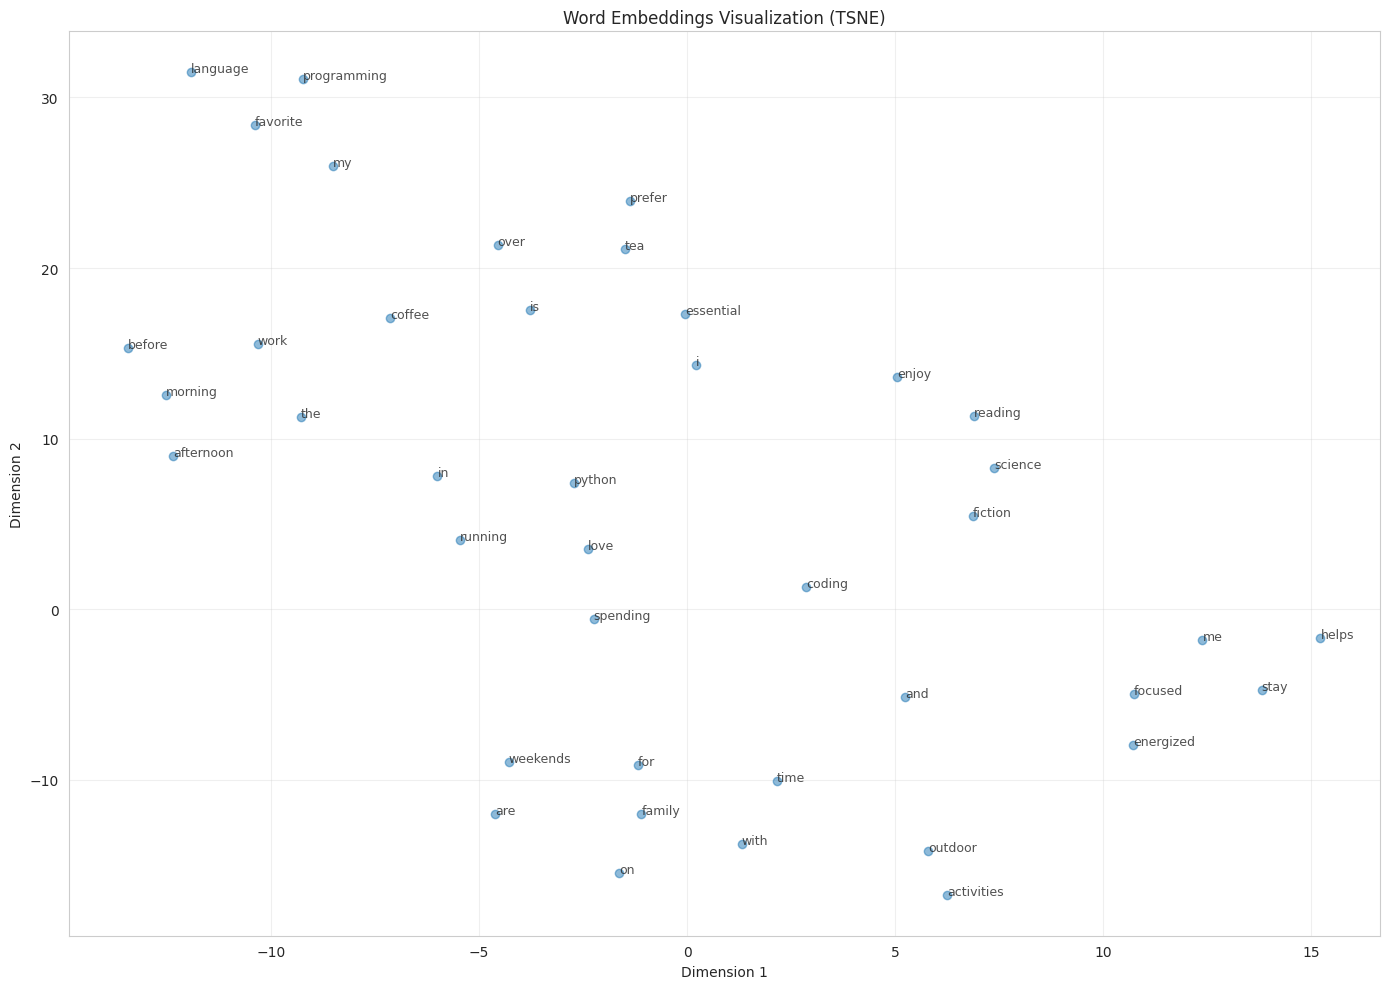

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Optional: color by known group if you have labels (word -> group)
colors = {"food": "tab:orange", "animal": "tab:green", "tech": "tab:blue",
          "school": "tab:red", "other": "tab:gray"}

def visualize_embeddings(tokenizer, embeddings, method='pca', word2group=None):
    words, vectors = [], []
    for word, idx in tokenizer.word_to_id.items():
        if not word.startswith('<'):
            words.append(word)
            vectors.append(embeddings.embeddings[idx])
    vectors = np.array(vectors)

    if method == 'pca':
        reducer = PCA(n_components=2)
    else:
        # perplexity must be < number of words
        reducer = TSNE(n_components=2, random_state=42,
                       perplexity=min(10, len(words) - 1))
    coords_2d = reducer.fit_transform(vectors)

    plt.figure(figsize=(14, 10))
    if word2group:
        for g, c in colors.items():
            m = [i for i, w in enumerate(words) if word2group.get(w, "other") == g]
            plt.scatter(coords_2d[m, 0], coords_2d[m, 1], c=c, alpha=0.6, s=60, label=g)
        plt.legend()
    else:
        plt.scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0.5)

    for i, word in enumerate(words):          # annotate ALL words (vocab is small)
        plt.annotate(word, (coords_2d[i, 0], coords_2d[i, 1]), fontsize=9, alpha=0.8)

    plt.title(f'Word Embeddings Visualization ({method.upper()})')
    plt.xlabel('Dimension 1'); plt.ylabel('Dimension 2')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

visualize_embeddings(tokenizer, trained_embeddings, method='pca')
visualize_embeddings(tokenizer, trained_embeddings, method='tsne')

---
## Part 3: LLM Architecture Overview

Now let's see how these components fit into the bigger picture.

### 3.1 The LLM Pipeline

In [11]:
class SimpleLLMPipeline:
    """
    Simplified LLM pipeline showing major components.
    """

    def __init__(self, tokenizer, embeddings):
        self.tokenizer = tokenizer
        self.embeddings = embeddings
        self.processing_steps = []

    def process(self, text, verbose=True):
        """
        Process text through the pipeline.

        Args:
            text: Input text
            verbose: Print intermediate steps

        Returns:
            dict: Processing results
        """
        results = {}

        # Step 1: Tokenization
        if verbose:
            print("Step 1: Tokenization")
            print("  Input text:", text)

        tokens = simple_tokenize(text)
        token_ids = self.tokenizer.encode(text)

        if verbose:
            print(f"  Tokens: {tokens}")
            print(f"  Token IDs: {token_ids}")

        results['tokens'] = tokens
        results['token_ids'] = token_ids

        # Step 2: Embedding
        if verbose:
            print("\nStep 2: Embedding")

        embedded = self.embeddings.embed(token_ids)

        if verbose:
            print(f"  Embedding shape: {embedded.shape}")
            print(f"  (sequence_length={len(token_ids)}, embedding_dim={embedded.shape[1]})")

        results['embeddings'] = embedded

        # Step 3: Attention (simplified - just mean pooling)
        if verbose:
            print("\nStep 3: Contextual Processing (Simplified)")

        # Simple mean pooling as placeholder
        contextualized = np.mean(embedded, axis=0)

        if verbose:
            print(f"  Contextualized representation shape: {contextualized.shape}")

        results['contextualized'] = contextualized

        # Step 4: Output projection (simplified)
        if verbose:
            print("\nStep 4: Output Generation (Simplified)")
            print("  → In real LLMs, this produces probability distribution over vocabulary")

        return results

# Create pipeline
pipeline = SimpleLLMPipeline(tokenizer, trained_embeddings)

# Test with digital twin input
test_input = "I love running and coding"
print("=" * 60)
print("PROCESSING THROUGH LLM PIPELINE")
print("=" * 60 + "\n")

results = pipeline.process(test_input, verbose=True)

print("\n" + "=" * 60)
print("✅ Processing complete!")
print("=" * 60)

PROCESSING THROUGH LLM PIPELINE

Step 1: Tokenization
  Input text: I love running and coding
  Tokens: ['i', 'love', 'running', 'and', 'coding']
  Token IDs: [4, 7, 8, 6, 24]

Step 2: Embedding
  Embedding shape: (5, 16)
  (sequence_length=5, embedding_dim=16)

Step 3: Contextual Processing (Simplified)
  Contextualized representation shape: (16,)

Step 4: Output Generation (Simplified)
  → In real LLMs, this produces probability distribution over vocabulary

✅ Processing complete!


### 🎯 Exercise 3.1 (Conceptual): Architecture Understanding

**Questions**:

1. Why is tokenization necessary before embedding?
2. What information is captured in embeddings?
3. What would happen if we skipped the embedding step and used one-hot encoding instead?
4. How does sequence length affect computational cost?
5. In a real LLM, what happens after the "contextual processing" step?

Write your answers below:

**ID No: ATF26-659079-NGA**

**Name: Zilzani Abdullahi**

**1. Why tokenization is necessary:**
Models operate on numbers, not raw text. Tokenization splits text into discrete units from a fixed vocabulary and maps each to an integer ID, which indexes a row in the embedding table. Without it, the model has no consistent, finite set of inputs to learn from. Subword tokenization (BPE, WordPiece) also handles rare and unseen words without `<UNK>` tokens.

**2. Information in embeddings:**
Each embedding is a dense vector learned during training. It captures:
- **Semantic similarity:** related words (e.g. "goat" and "sheep") end up close together.
- **Syntactic and usage patterns:** part of speech, typical neighbors, grammatical role.
- **Relational structure:** directions in the space can encode relations (e.g. singular → plural).

In a transformer, positional information is added to these vectors, and context-specific meaning is built up in later layers.

**3. One-hot encoding vs embeddings:**
- **Size:** each vector has as many dimensions as the vocabulary (50,000+ for real LLMs), almost all zeros. This wastes memory and compute.
- **No similarity:** every pair of words is equally distant (orthogonal), so "goat" is no closer to "sheep" than to "server". The model must learn every relationship from scratch.
- **Poor generalization:** what the model learns about one word doesn't transfer to similar words.

Embeddings compress each token into a few hundred or thousand dimensions and place similar words near each other. (A one-hot vector multiplied by a weight matrix is just a lookup of one embedding row, so an embedding layer is a learned, efficient version of the same operation.)

**4. Sequence length impact:**
Self-attention compares every token with every other token, so cost grows **quadratically (O(n²))** in time and memory. Doubling the sequence length roughly quadruples the attention cost. The feed-forward layers scale linearly (O(n)). This is why context windows are limited, and why techniques like sparse attention, FlashAttention, and KV caching exist.

**5. After contextual processing:**
The transformer layers (attention + feed-forward) produce a context-aware vector for each position. Then:
1. **Output projection:** the final vector at the last position is multiplied by a matrix to produce one score (logit) per vocabulary token.
2. **Softmax:** the logits become a probability distribution over the next token.
3. **Sampling or selection:** a token is chosen (greedy, temperature, top-k, or top-p sampling).
4. **Detokenization and loop:** the token is converted back to text, appended to the input, and the process repeats until a stop token or length limit.

**Your Answers:**

1. Why tokenization is necessary:
   -

2. Information in embeddings:
   -

3. One-hot encoding vs embeddings:
   -

4. Sequence length impact:
   -

5. After contextual processing:
   -

### 3.2 Comparing Different Embedding Dimensions

In [12]:
# Experiment with different embedding dimensions
dimensions = [4, 8, 16, 32]

print("Comparing embedding dimensions:\n")
for dim in dimensions:
    emb = SimpleEmbedding(vocab_size, dim)

    # Calculate memory usage
    memory_mb = (vocab_size * dim * 4) / (1024 * 1024)  # 4 bytes per float

    print(f"Dimension {dim}:")
    print(f"  Parameters: {vocab_size * dim:,}")
    print(f"  Memory: {memory_mb:.2f} MB")
    print(f"  Expressiveness: {'Low' if dim < 16 else 'Medium' if dim < 64 else 'High'}")
    print()

Comparing embedding dimensions:

Dimension 4:
  Parameters: 180
  Memory: 0.00 MB
  Expressiveness: Low

Dimension 8:
  Parameters: 360
  Memory: 0.00 MB
  Expressiveness: Low

Dimension 16:
  Parameters: 720
  Memory: 0.00 MB
  Expressiveness: Medium

Dimension 32:
  Parameters: 1,440
  Memory: 0.01 MB
  Expressiveness: Medium



### 🎯 Exercise 3.2 (Advanced): Build a Mini Language Model

**Task**: Create a simple language model that can predict the next word.

**Requirements**:
1. Use the tokenizer and embeddings we created
2. Implement a simple prediction mechanism
3. Test with different input sequences
4. Measure prediction accuracy

**Hint**: You can use the embeddings to find the most similar word to a context representation.

In [18]:
import numpy as np
from collections import defaultdict, Counter

class MiniLanguageModel:
    def __init__(self, tokenizer, embeddings, corpus):
        self.tokenizer = tokenizer
        self.embeddings = embeddings
        self.corpus = corpus
        E = embeddings.embeddings
        self.E_norm = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)
        self.context_patterns = self._build_patterns()

    def _build_patterns(self):
        """context (1 or 2 words) -> Counter of next words."""
        patterns = {1: defaultdict(Counter), 2: defaultdict(Counter)}
        for s in self.corpus:
            w = self.tokenizer.tokenize(s)
            for i in range(1, len(w)):
                patterns[1][tuple(w[i-1:i])][w[i]] += 1
                if i >= 2:
                    patterns[2][tuple(w[i-2:i])][w[i]] += 1
        return patterns

    def _embedding_fallback(self, words, k):
        """Unseen context: average the context embeddings, return most similar words."""
        ids = [self.tokenizer.word_to_id[w] for w in words if w in self.tokenizer.word_to_id]
        if not ids:
            return []
        sims = self.E_norm @ self.E_norm[ids].mean(0)
        for i in [0, 1] + ids:                    # mask <PAD>, <UNK>, context words
            sims[i] = -9
        return [self.tokenizer.id_to_word[i] for i in np.argsort(-sims)[:k]]

    def predict_top_k(self, context, k=3):
        w = self.tokenizer.tokenize(context)
        for n in (2, 1):                          # backoff: 2-word context -> 1-word
            key = tuple(w[-n:])
            if len(w) >= n and key in self.context_patterns[n]:
                return [x for x, _ in self.context_patterns[n][key].most_common(k)]
        return self._embedding_fallback(w, k)

    def predict_next_word(self, context):
        p = self.predict_top_k(context, 1)
        return p[0] if p else "<UNK>"

    def generate_sequence(self, start_text, num_words=5, temperature=0.0):
        words = self.tokenizer.tokenize(start_text)
        for _ in range(num_words):
            cands = None
            for n in (2, 1):
                key = tuple(words[-n:])
                if len(words) >= n and key in self.context_patterns[n]:
                    cands = self.context_patterns[n][key]
                    break
            if cands is None:
                nxt = self.predict_next_word(" ".join(words))
            elif temperature == 0:
                nxt = cands.most_common(1)[0][0]
            else:                                  # sample proportional to counts^(1/T)
                ws, cs = zip(*cands.items())
                p = np.array(cs, float) ** (1 / temperature)
                nxt = np.random.choice(ws, p=p / p.sum())
            words.append(nxt)
        return " ".join(words)

    def evaluate(self, sentences, k=3):
        top1 = topk = total = 0
        for s in sentences:
            w = self.tokenizer.tokenize(s)
            for i in range(1, len(w)):
                preds = self.predict_top_k(" ".join(w[:i]), k)
                top1 += bool(preds) and preds[0] == w[i]
                topk += w[i] in preds
                total += 1
        return {"top1": top1 / total, f"top{k}": topk / total, "n": total}


---
## Part 4: Digital Twin Integration

Let's bring everything together for our digital twin!

### 4.1 Digital Twin Language Encoder

In [17]:
class DigitalTwinEncoder:
    """
    Encode user descriptions into vector representations.
    """

    def __init__(self, tokenizer, embeddings):
        self.tokenizer = tokenizer
        self.embeddings = embeddings
        self.user_profile = None

    def encode_user(self, description):
        """
        Encode user description into a profile vector.

        Args:
            description: User description text

        Returns:
            np.array: User profile vector
        """
        # Tokenize
        token_ids = self.tokenizer.encode(description)

        # Embed
        embedded = self.embeddings.embed(token_ids)

        # Pool (mean pooling)
        profile = np.mean(embedded, axis=0)

        self.user_profile = profile
        return profile

    def compare_descriptions(self, desc1, desc2):
        """
        Compare similarity between two descriptions.

        Args:
            desc1, desc2: Description texts

        Returns:
            float: Similarity score
        """
        profile1 = self.encode_user(desc1)
        profile2 = self.encode_user(desc2)

        # Cosine similarity
        similarity = np.dot(profile1, profile2) / (
            np.linalg.norm(profile1) * np.linalg.norm(profile2)
        )

        return similarity

    def find_interests(self, description):
        """
        Extract key interests from description.

        Args:
            description: User description

        Returns:
            list: Key interest words
        """
        tokens = simple_tokenize(description)
        token_ids = self.tokenizer.encode(description)

        # Get embeddings
        embedded = self.embeddings.embed(token_ids)

        # Find tokens with highest norm (most "important")
        norms = np.linalg.norm(embedded, axis=1)
        top_indices = np.argsort(norms)[-5:][::-1]

        interests = [tokens[i] for i in top_indices if i < len(tokens)]
        return interests

# Create digital twin encoder
twin_encoder = DigitalTwinEncoder(tokenizer, trained_embeddings)

# Test with different user profiles
user1 = "I love running and outdoor sports. Coffee enthusiast."
user2 = "I enjoy coding in Python and building AI systems."
user3 = "I love running and coding in Python."

print("User Profile Encoding:\n")
profile1 = twin_encoder.encode_user(user1)
print(f"User 1 profile shape: {profile1.shape}")
print(f"Profile vector (first 8 dims): {profile1[:8]}")

print("\n" + "="*60)
print("Comparing User Profiles:\n")

sim_1_2 = twin_encoder.compare_descriptions(user1, user2)
sim_1_3 = twin_encoder.compare_descriptions(user1, user3)
sim_2_3 = twin_encoder.compare_descriptions(user2, user3)

print(f"User 1 vs User 2 similarity: {sim_1_2:.3f}")
print(f"User 1 vs User 3 similarity: {sim_1_3:.3f}")
print(f"User 2 vs User 3 similarity: {sim_2_3:.3f}")

print("\n" + "="*60)
print("Detected Interests:\n")

for i, user in enumerate([user1, user2, user3], 1):
    interests = twin_encoder.find_interests(user)
    print(f"User {i}: {interests}")

User Profile Encoding:

User 1 profile shape: (16,)
Profile vector (first 8 dims): [ 0.33866163 -0.07237815  0.13469448  0.21867139 -0.04905753  0.12383126
  0.24739396 -0.10105272]

Comparing User Profiles:

User 1 vs User 2 similarity: 0.985
User 1 vs User 3 similarity: 0.988
User 2 vs User 3 similarity: 0.968

Detected Interests:

User 1: ['and', 'i', 'coffee', 'running', 'love']
User 2: ['and', 'in', 'i', 'python', 'enjoy']
User 3: ['and', 'in', 'i', 'running', 'love']


### 🎯 Exercise 4.1 (Intermediate): Build Your Digital Twin Profile

**Task**: Create and analyze your own digital twin profile.

**Steps**:
1. Write a detailed description of yourself (interests, habits, preferences)
2. Encode it using the digital twin encoder
3. Compare it with other example profiles
4. Identify detected interests
5. Test how similar descriptions affect similarity scores

In [19]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. My description
my_description = """
I am an education officer and examination officer at a primary school in Tsafe, Zamfara State, Nigeria.
I hold a B.Sc. in Computer Science and I am pursuing an M.Sc. in Artificial Intelligence at Ahmadu Bello University.
I love programming and building software: school management systems, a hotel booking app with Flutter, Node and PostgreSQL,
and a mobile food delivery app. I enjoy machine learning, data and language models.
I also run a livestock business, selling goats, rams and cows, and I create social media content to attract customers.
I write English lessons and a textbook for beginners in primary school, and I teach in English and Hausa.
"""

profiles = {
    "Software engineer": "I write code every day, build apps and servers with python and javascript, use databases and cloud software, and love open source programming.",
    "AI/ML student":     "I study artificial intelligence and machine learning, train neural network models on data, read research papers and write python code.",
    "Primary teacher":   "I am a teacher at a primary school. I prepare lessons, mark exams, teach children to read and write, and work with pupils and parents.",
    "Livestock farmer":  "I raise goats, cows and sheep on my farm, sell animals at the market, feed my herd and manage a small agriculture business.",
    "Chef / foodie":     "I love cooking rice, soup and bread, trying new recipes, running a small restaurant and sharing food photos with friends.",
    "Footballer":        "I play football every weekend, train at the gym, run for fitness and watch matches with my team.",
    "Content creator":   "I make videos and posts for social media, plan content, grow followers and create engaging stories for my audience.",
}

interests = {
    "technology/programming": "software code programming app apps developer flutter node python database server mobile web system systems build",
    "artificial intelligence": "artificial intelligence machine learning model models neural data language research training algorithm",
    "education/teaching":      "school teacher teaching lessons exam examination pupils students textbook education learning children primary",
    "agriculture/livestock":   "livestock goats rams cows sheep farm animals market herd selling agriculture",
    "business/marketing":      "business customers selling sales market marketing social media content brand attract",
    "languages":               "english hausa language translate bilingual writing speak vocabulary",
    "food":                    "food cooking recipe rice soup restaurant delivery",
    "sports/fitness":          "football gym training run fitness match team sport",
}

# 2. Encoder
class DigitalTwinEncoder:
    def __init__(self, reference_texts):
        self.vec = TfidfVectorizer(stop_words="english", sublinear_tf=True)
        self.vec.fit(reference_texts)
    def encode(self, text):
        return self.vec.transform([text])
    def similarity(self, a, b):
        return float(cosine_similarity(self.encode(a), self.encode(b))[0, 0])

enc = DigitalTwinEncoder(list(profiles.values()) + list(interests.values()) + [my_description])
print("Encoded shape:", enc.encode(my_description).shape)

# 3. Compare with example profiles
print("\n== Similarity to example profiles ==")
sims = {n: enc.similarity(my_description, t) for n, t in profiles.items()}
for n, s in sorted(sims.items(), key=lambda x: -x[1]):
    print(f"{n:20} {s:.3f}  {'#' * int(s * 60)}")

# 4. Detected interests
print("\n== Detected interests ==")
isc = {n: enc.similarity(my_description, t) for n, t in interests.items()}
for n, s in sorted(isc.items(), key=lambda x: -x[1]):
    print(f"{n:24} {s:.3f}  {'#' * int(s * 60)}")

# 5. Effect of changing the description
tests = {
    "Identical":               my_description,
    "Tech + AI only":          "I am pursuing an M.Sc. in Artificial Intelligence and I love programming, building software and mobile apps with databases.",
    "Teaching only":           "I am a primary school teacher and examination officer who writes English lessons and a textbook for pupils.",
    "Livestock only":          "I run a livestock business selling goats, rams and cows at the market.",
    "Paraphrase (synonyms)":   "I work in schools administration, study machine intelligence at university, develop applications, and trade in cattle and sheep online.",
    "Shuffled word order":     " ".join(np.random.RandomState(0).permutation(my_description.split())),
    "Repeated 3x":             my_description * 3,
    "Unrelated (football fan)":"I watch football matches, go to the gym, run every morning and support my favourite team.",
}
print("\n== Similarity to my profile ==")
for n, t in tests.items():
    print(f"{n:26} {enc.similarity(my_description, t):.3f}")

Encoded shape: (1, 148)

== Similarity to example profiles ==
Primary teacher      0.167  #########
AI/ML student        0.160  #########
Content creator      0.101  ######
Software engineer    0.086  #####
Livestock farmer     0.073  ####
Chef / foodie        0.045  ##
Footballer           0.028  #

== Detected interests ==
education/teaching       0.241  ##############
technology/programming   0.215  ############
business/marketing       0.212  ############
artificial intelligence  0.190  ###########
agriculture/livestock    0.160  #########
languages                0.132  #######
food                     0.078  ####
sports/fitness           0.032  #

== Similarity to my profile ==
Identical                  1.000
Tech + AI only             0.341
Teaching only              0.383
Livestock only             0.267
Paraphrase (synonyms)      0.132
Shuffled word order        1.000
Repeated 3x                0.995
Unrelated (football fan)   0.037


---
## Summary & Key Takeaways

### What We Learned:

1. **Tokenization**: Converting text into processable units
   - Word-level vs subword tokenization
   - Vocabulary size trade-offs
   - Handling unknown words

2. **Embeddings**: Dense vector representations of tokens
   - Capture semantic similarity
   - Learn from co-occurrence patterns
   - Enable mathematical operations on meaning

3. **LLM Architecture**: How components work together
   - Tokenization → Embedding → Processing → Output
   - Each step transforms representation
   - Trade-offs between size and capability

4. **Digital Twin Application**: Practical use of these concepts
   - Encoding user profiles
   - Comparing descriptions
   - Interest extraction

### Next Steps:
In the next notebook, we'll explore:
- The Transformer architecture
- Attention mechanisms
- How context is processed
- Building an attention-based digital twin

---
## 🏆 Challenge Project (Advanced)

**Enhanced Digital Twin Language System**

Build a complete system that:

1. **Data Collection**: Gather multiple user descriptions
2. **Training**: Train better embeddings on this data
3. **Clustering**: Group similar users together
4. **Recommendation**: Suggest connections between users
5. **Visualization**: Create an interactive visualization of the user embedding space

**Bonus Challenges**:
- Implement different embedding training methods (CBOW, Skip-gram)
- Add sentiment analysis to profiles
- Create a simple search engine for finding similar users
- Build a recommendation system based on profile similarity

In [20]:
# YOUR CHALLENGE PROJECT CODE HERE
# %% [markdown]
# # Enhanced Digital Twin Language System
# Data collection -> embedding training (CBOW / Skip-gram) -> clustering ->
# recommendations -> search -> sentiment -> interactive visualization.
# Needs: numpy, scikit-learn, plotly   (pip install plotly)

# %% 0. Imports
import re, random, math
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.graph_objects as go

SEED = 42
rng = random.Random(SEED)
np.random.seed(SEED)

# %% 1. DATA COLLECTION
# Synthetic users: each has a primary interest archetype, sometimes a secondary one.
ARCHETYPES = {
    "developer": [
        "I build mobile apps with Flutter and write backend code in Node.",
        "I love programming and debugging software late at night.",
        "I design databases and web servers for small businesses.",
        "I am learning new programming languages and frameworks.",
        "I write clean code and deploy apps to the cloud.",
        "I enjoy solving software problems and building developer tools.",
        "I use git, APIs and databases to ship web applications.",
        "I am proud of the management systems and apps I have developed.",
    ],
    "ai": [
        "I study machine learning and train neural network models on data.",
        "I read research papers about language models and embeddings.",
        "I love experimenting with algorithms and measuring model accuracy.",
        "I work with python, tensors and datasets for artificial intelligence research.",
        "I am fascinated by transformers, attention and natural language processing.",
        "I enjoy cleaning data and evaluating classifiers and predictions.",
        "I am writing a thesis on deep learning and intelligent systems.",
        "I follow new research on language models and neural networks.",
    ],
    "education": [
        "I teach children to read and write in primary school.",
        "I prepare lessons, mark exams and track pupil progress.",
        "I love helping students understand hard topics in class.",
        "I write textbooks and worksheets for beginners learning English.",
        "I coordinate examinations and manage school records.",
        "I work with parents and teachers to improve learning outcomes.",
        "I enjoy designing classroom activities and curriculum plans.",
        "I believe good education changes communities.",
    ],
    "livestock": [
        "I raise goats, rams and cows on my farm.",
        "I sell cattle and sheep at the weekly livestock market.",
        "I feed my herd with fodder and care for animal health.",
        "I work with a veterinary doctor to vaccinate my animals.",
        "I love agriculture and managing a growing farm business.",
        "I negotiate prices with buyers and traders before every festival.",
        "I keep records of feed, breeding and sales for each animal.",
        "I am planning to expand my herd and supply more markets.",
    ],
    "food": [
        "I love cooking rice, soup and fresh bread for my family.",
        "I try new recipes and spices in my kitchen every weekend.",
        "I run a small restaurant and deliver meals to customers.",
        "I enjoy baking cakes and sharing food photos with friends.",
        "I plan menus, buy fresh vegetables and manage kitchen staff.",
        "I am passionate about local dishes and street food.",
        "I learn about nutrition and healthy meals.",
        "I take orders for catering at weddings and events.",
    ],
    "sports": [
        "I play football every weekend with my team.",
        "I train at the gym and run each morning for fitness.",
        "I watch matches and follow the league table closely.",
        "I coach young players and organise friendly tournaments.",
        "I love basketball, athletics and staying active.",
        "I track my training, stamina and recovery.",
        "I support my favourite club and travel to watch games.",
        "I enjoy competition, teamwork and winning matches.",
    ],
    "creator": [
        "I make videos and posts for social media every day.",
        "I plan content calendars and grow followers online.",
        "I love storytelling and creating engaging captions for my audience.",
        "I edit short videos, design thumbnails and study analytics.",
        "I work with brands to promote products on social platforms.",
        "I enjoy photography, filming and sharing stories online.",
        "I measure likes, shares, reach and engagement for every post.",
        "I am building a personal brand and a loyal community.",
    ],
    "business": [
        "I run a small shop and manage stock, customers and profits.",
        "I negotiate with suppliers and track sales every week.",
        "I love entrepreneurship and finding new market opportunities.",
        "I keep accounts, invoices and records for my business.",
        "I use mobile payments and promote my products on social media.",
        "I plan budgets, save profits and reinvest in the business.",
        "I attend trade fairs and build relationships with buyers.",
        "I want to grow my business and hire more staff.",
    ],
}
GENERIC_POS = [
    "I enjoy meeting new people and learning from others.",
    "I love living in northern Nigeria and speaking Hausa and English.",
    "I am excited to collaborate on new projects.",
]
GENERIC_NEG = [
    "I get frustrated when plans are delayed.",
    "I struggle to find enough time for everything.",
    "I dislike wasting time and resources.",
    "I am worried about rising costs and unreliable electricity.",
    "I hate when the internet is slow and unreliable.",
]
NAMES = ["Aisha", "Musa", "Chinedu", "Fatima", "Ibrahim", "Ngozi", "Sani", "Amina", "Tunde", "Zainab",
         "Emeka", "Hauwa", "Yusuf", "Bola", "Halima", "Kabiru", "Ifeoma", "Garba", "Maryam", "Segun",
         "Nkechi", "Bashir", "Rukayya", "Femi", "Abubakar", "Chioma", "Salisu", "Binta", "Kunle", "Adaeze",
         "Lawal", "Hadiza", "Obinna", "Jamila", "Tijani", "Uche", "Safiya", "Dauda", "Folake", "Idris",
         "Nana", "Shehu", "Titi", "Auwal", "Blessing", "Yakubu", "Ronke", "Sadiq", "Ebere", "Habiba",
         "Gbenga", "Khadija", "Ahmed", "Joy", "Umar", "Sade", "Danjuma", "Zara", "Ikenna", "Lami"]


class UserStore:
    """Collects user descriptions (name -> text, optional ground-truth label)."""
    def __init__(self):
        self.names, self.texts, self.labels = [], [], []
    def add(self, name, text, label=None):
        self.names.append(name); self.texts.append(" ".join(text.split())); self.labels.append(label)
    def __len__(self):
        return len(self.names)
    def index(self, name):
        return self.names.index(name)


def generate_users(per_archetype=7):
    store = UserStore()
    names = NAMES[:]; rng.shuffle(names)
    for arch, pool in ARCHETYPES.items():
        for _ in range(per_archetype):
            sents = rng.sample(pool, rng.randint(4, 5))
            if rng.random() < 0.35:                                   # secondary interest
                other = rng.choice([a for a in ARCHETYPES if a != arch])
                sents += rng.sample(ARCHETYPES[other], rng.randint(2, 3))
            sents += rng.sample(GENERIC_POS, rng.randint(0, 2))
            sents += rng.sample(GENERIC_NEG, rng.choices([0, 1, 2, 3], weights=[3, 4, 2, 1])[0])
            rng.shuffle(sents)
            store.add(names.pop(), " ".join(sents), label=arch)
    return store


store = generate_users()
store.add("Abdullahi", """
I am an education officer and examination officer at a primary school in Tsafe, Zamfara State, Nigeria.
I hold a bachelor degree in computer science and I am pursuing a master degree in artificial intelligence.
I love programming and building software: school management systems, a hotel booking app with Flutter, Node and PostgreSQL,
and a mobile food delivery app. I enjoy machine learning, data and language models.
I also run a livestock business, selling goats, rams and cows, and I create social media content to attract customers.
I write English lessons and a textbook for beginners in primary school, and I teach in English and Hausa.
""", label=None)
print(f"Collected {len(store)} user descriptions")

# %% 2. TOKENIZATION + EMBEDDING TRAINING (CBOW and Skip-gram with negative sampling)
def content_tokens(text):
    return [w for w in re.findall(r"[a-z]{2,}", text.lower()) if w not in ENGLISH_STOP_WORDS]

def split_sentences(text):
    return [s for s in re.split(r"[.!?]+\s*", text) if s.strip()]

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -10, 10)))


class WordEmbedder:
    """Word2Vec in numpy. method='skipgram' (word -> context) or 'cbow' (context -> word)."""
    def __init__(self, method="skipgram", dim=32, window=3, neg=5, epochs=40, lr=0.05, seed=0):
        self.method, self.dim, self.window, self.neg = method, dim, window, neg
        self.epochs, self.lr, self.seed = epochs, lr, seed

    def fit(self, sentences):
        counts = Counter(w for s in sentences for w in s)
        self.itos = sorted(counts); self.stoi = {w: i for i, w in enumerate(self.itos)}
        V, D, W = len(self.itos), self.dim, self.window
        rs = np.random.RandomState(self.seed)
        W_in = (rs.rand(V, D) - 0.5) / D
        W_out = np.zeros((V, D))
        noise = np.array([counts[w] for w in self.itos], float) ** 0.75
        noise /= noise.sum()
        ids = [[self.stoi[w] for w in s] for s in sentences if len(s) > 1]
        cbow = self.method == "cbow"

        X, Y = [], []
        for s in ids:
            for i, c in enumerate(s):
                ctx = [s[j] for j in range(max(0, i - W), min(len(s), i + W + 1)) if j != i]
                if cbow:
                    X.append(ctx + [-1] * (2 * W - len(ctx))); Y.append(c)
                else:
                    for o in ctx:
                        X.append(c); Y.append(o)
        X, Y = np.array(X), np.array(Y)
        n, bs = len(Y), (128 if cbow else 256)
        total, step = self.epochs * math.ceil(n / bs), 0

        for _ in range(self.epochs):
            perm = rs.permutation(n)
            for b in range(0, n, bs):
                idx = perm[b:b + bs]; B = len(idx)
                lr = max(self.lr * (1 - step / total), self.lr * 0.05); step += 1
                y = Y[idx]
                negs = rs.choice(V, size=(B, self.neg), p=noise)
                if cbow:
                    cx = X[idx]; mask = cx >= 0; safe = np.where(mask, cx, 0)
                    cnt = mask.sum(1, keepdims=True)
                    h = (W_in[safe] * mask[:, :, None]).sum(1) / cnt
                else:
                    x = X[idx]; h = W_in[x]
                uo, un = W_out[y], W_out[negs]
                gp = sigmoid((h * uo).sum(1)) - 1                       # positive pair gradient
                gn = sigmoid(np.einsum("bd,bkd->bk", h, un))            # negative samples gradient
                dh = gp[:, None] * uo + np.einsum("bk,bkd->bd", gn, un)
                np.add.at(W_out, y, -lr * gp[:, None] * h)
                np.add.at(W_out, negs, -lr * gn[:, :, None] * h[:, None, :])
                if cbow:
                    np.add.at(W_in, safe, -lr * (dh / cnt)[:, None, :] * mask[:, :, None])
                else:
                    np.add.at(W_in, x, -lr * dh)
        self.W = W_in
        return self

    def vec(self, word):
        i = self.stoi.get(word)
        return np.zeros(self.dim) if i is None else self.W[i]

    def most_similar(self, word, k=5):
        E = self.W / (np.linalg.norm(self.W, axis=1, keepdims=True) + 1e-9)
        s = E @ E[self.stoi[word]]
        return [self.itos[i] for i in np.argsort(-s)[1:k + 1]]


# %% 3. USER ENCODER (TF-IDF, CBOW, Skip-gram, hybrid)
def l2(M):
    return M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)


class TwinEncoder:
    def __init__(self, texts, dim=32, epochs=40):
        self.tfidf = TfidfVectorizer(analyzer=content_tokens, sublinear_tf=True).fit(texts)
        self.terms = self.tfidf.get_feature_names_out()
        sents = [s for t in texts for s in map(content_tokens, split_sentences(t)) if len(s) > 1]
        self.models = {m: WordEmbedder(m, dim=dim, epochs=epochs).fit(sents) for m in ("cbow", "skipgram")}
        self.term_matrix = {m: np.array([e.vec(w) for w in self.terms]) for m, e in self.models.items()}

    def encode(self, texts, method="hybrid"):
        if isinstance(texts, str):
            texts = [texts]
        X = self.tfidf.transform(texts)
        if method == "tfidf":
            return l2(X.toarray())
        if method in ("cbow", "skipgram"):
            return l2(np.asarray(X @ self.term_matrix[method]))
        return np.hstack([l2(X.toarray()), l2(np.asarray(X @ self.term_matrix["skipgram"]))]) / np.sqrt(2)


enc = TwinEncoder(store.texts)

print("\n== Nearest words (what the embeddings learned) ==")
for w in ["goats", "python", "teach", "football"]:
    for m in ("cbow", "skipgram"):
        print(f"{w:9} {m:9} -> {enc.models[m].most_similar(w, 5)}")


def precision_at_k(V, labels, k=3):
    S = V @ V.T; np.fill_diagonal(S, -1); hits = []
    for i, l in enumerate(labels):
        if l is not None:
            top = np.argsort(-S[i])[:k]
            hits.append(np.mean([labels[j] == l for j in top]))
    return float(np.mean(hits))


print("\n== Which encoder finds the best neighbours? (precision@3 vs. true interest) ==")
METHODS = ["tfidf", "cbow", "skipgram", "hybrid"]
mats = {m: enc.encode(store.texts, m) for m in METHODS}
scores = {m: precision_at_k(mats[m], store.labels) for m in METHODS}
for m, s in scores.items():
    print(f"{m:9} {s:.3f}  {'#' * int(s * 40)}")
BEST = max(scores, key=lambda m: (round(scores[m], 3), m == "hybrid"))   # ties -> hybrid
print("Using:", BEST)
V = mats[BEST]; S = V @ V.T

# %% 4. CLUSTERING
print("\n== Clustering (KMeans, k chosen by silhouette) ==")
sil = {}
for k in range(5, 11):
    sil[k] = silhouette_score(V, KMeans(k, n_init=10, random_state=SEED).fit_predict(V))
    print(f"k={k:<2} silhouette={sil[k]:.3f}")
K = max(sil, key=sil.get)
clusters = KMeans(K, n_init=10, random_state=SEED).fit_predict(V)
known = [i for i, l in enumerate(store.labels) if l is not None]
print(f"Chosen k={K} | adjusted Rand vs. true interests: "
      f"{adjusted_rand_score([store.labels[i] for i in known], clusters[known]):.3f}")

TF = enc.tfidf.transform(store.texts).toarray()
cluster_names = {}
for c in range(K):
    members = np.where(clusters == c)[0]
    top = np.argsort(-TF[members].mean(0))[:3]
    cluster_names[c] = ", ".join(enc.terms[top])
    print(f"Cluster {c} ({len(members)} users): {cluster_names[c]}  ->  "
          f"{', '.join(store.names[i] for i in members[:6])}{'...' if len(members) > 6 else ''}")

# %% 5. SENTIMENT ANALYSIS (lexicon + negation)
POS = {"love", "enjoy", "proud", "excited", "fascinated", "passionate", "believe", "healthy", "growing",
       "loyal", "good", "great", "fresh", "engaging", "winning", "clean", "improve", "friendly"}
NEG = {"frustrated", "struggle", "dislike", "hate", "worried", "wasting", "unreliable", "delayed",
       "slow", "rising", "problem", "problems"}
NEGATORS = {"not", "never", "no", "hardly"}


def sentiment(text):
    pos = neg = 0
    for sent in split_sentences(text):
        toks = re.findall(r"[a-z']+", sent.lower())
        for i, t in enumerate(toks):
            s = 1 if t in POS else -1 if t in NEG else 0
            if s and i > 0 and toks[i - 1] in NEGATORS:
                s = -s
            pos += s > 0; neg += s < 0
    score = (pos - neg) / (pos + neg + 1)
    label = "positive" if score > 0.3 else "negative" if score < -0.1 else "mixed"
    return score, label


sent = [sentiment(t) for t in store.texts]
print("\n== Sentiment ==")
print(Counter(l for _, l in sent))
for c in range(K):
    m = np.where(clusters == c)[0]
    print(f"Cluster {c}: mean sentiment {np.mean([sent[i][0] for i in m]):+.2f}")

# %% 6. RECOMMENDATION (profile similarity + explanation)
def shared_terms(i, j, n=3):
    common = np.minimum(TF[i], TF[j])
    top = np.argsort(-common)[:n]
    return [enc.terms[t] for t in top if common[t] > 0]


def recommend(name, n=3, cross_cluster=False):
    i = store.index(name); s = S[i].copy(); s[i] = -1
    if cross_cluster:
        s[clusters == clusters[i]] = -1
    return [(store.names[j], float(s[j]), int(clusters[j]), shared_terms(i, j)) for j in np.argsort(-s)[:n]]


def show_recs(name, n=3, cross_cluster=False):
    kind = "cross-cluster (new worlds)" if cross_cluster else "most similar"
    print(f"\nRecommended connections for {name} - {kind}:")
    for other, sc, c, sh in recommend(name, n, cross_cluster):
        why = ", ".join(sh) if sh else "related vocabulary"
        print(f"  {other:10} sim={sc:.2f} | cluster {c} | shared: {why}")


print("\n== Recommendations ==")
show_recs("Abdullahi", 3)
show_recs("Abdullahi", 3, cross_cluster=True)
show_recs(store.names[0], 3)

# %% 7. SEARCH ENGINE
def search(query, k=3, method=BEST):
    q = enc.encode(query, method)
    sims = (mats[method] @ q.T).ravel()
    return [(store.names[i], float(sims[i]), store.labels[i]) for i in np.argsort(-sims)[:k]]


print("\n== Search engine ==")
for q in ["someone who builds mobile apps", "raising cattle and selling at the market",
          "teaching children to read", "language models and neural networks",
          "cooking and catering for events"]:
    print(f"\n'{q}'")
    for name, sc, lab in search(q):
        print(f"  {name:10} {sc:.2f}  ({lab or 'you'})")

# %% 8. INTERACTIVE VISUALIZATION (plotly)
def visualize(method="tsne", highlight="Abdullahi", out_html="user_embedding_space.html"):
    if method == "tsne":
        xy = TSNE(2, perplexity=12, metric="cosine", init="pca", random_state=SEED).fit_transform(V)
    else:
        xy = PCA(2).fit_transform(V)
    symbols = {"positive": "circle", "mixed": "diamond", "negative": "x"}
    fig = go.Figure()
    for c in range(K):
        m = [i for i in np.where(clusters == c)[0] if store.names[i] != highlight]
        hover = [f"<b>{store.names[i]}</b><br>cluster {c}: {cluster_names[c]}"
                 f"<br>sentiment: {sent[i][1]} ({sent[i][0]:+.2f})"
                 f"<br>top terms: {', '.join(enc.terms[np.argsort(-TF[i])[:4]])}"
                 f"<br><i>{split_sentences(store.texts[i])[0][:70]}</i>" for i in m]
        fig.add_trace(go.Scatter(
            x=xy[m, 0], y=xy[m, 1], mode="markers", name=f"C{c}: {cluster_names[c]}",
            marker=dict(size=11, symbol=[symbols[sent[i][1]] for i in m], line=dict(width=1, color="white")),
            text=hover, hoverinfo="text"))
    if highlight in store.names:
        h = store.index(highlight)
        for other, sc, _, sh in recommend(highlight, 3):
            j = store.index(other)
            fig.add_trace(go.Scatter(x=[xy[h, 0], xy[j, 0]], y=[xy[h, 1], xy[j, 1]], mode="lines",
                                     line=dict(dash="dot", width=1.5, color="gray"),
                                     hoverinfo="skip", showlegend=False))
        fig.add_trace(go.Scatter(x=[xy[h, 0]], y=[xy[h, 1]], mode="markers+text", text=[highlight],
                                 textposition="top center", name=f"{highlight} (you)",
                                 marker=dict(size=20, symbol="star", color="gold", line=dict(width=2, color="black")),
                                 hovertext=f"<b>{highlight}</b><br>dotted lines = top recommended connections",
                                 hoverinfo="text"))
    fig.update_layout(title=f"User embedding space ({BEST} encoder, {method.upper()}) - "
                            "colour = cluster, shape = sentiment (circle +, diamond mixed, x -)",
                      template="plotly_white", height=720, legend=dict(font=dict(size=10)),
                      xaxis=dict(visible=False), yaxis=dict(visible=False))
    fig.write_html(out_html, include_plotlyjs="cdn")
    return fig


fig = visualize("tsne")
print("\nSaved interactive map: user_embedding_space.html")
fig.show()    # in Jupyter / Colab this renders inline

Collected 57 user descriptions

== Nearest words (what the embeddings learned) ==
goats     cbow      -> ['rams', 'cows', 'raise', 'create', 'attract']
goats     skipgram  -> ['rams', 'raise', 'cows', 'selling', 'farm']
python    cbow      -> ['tensors', 'work', 'datasets', 'vaccinate', 'veterinary']
python    skipgram  -> ['tensors', 'datasets', 'master', 'bachelor', 'intelligence']
teach     cbow      -> ['textbook', 'school', 'primary', 'children', 'write']
teach     skipgram  -> ['primary', 'children', 'textbook', 'zamfara', 'tsafe']
football  cbow      -> ['team', 'play', 'weekend', 'attract', 'supply']
football  skipgram  -> ['play', 'team', 'weekend', 'spices', 'recipes']

== Which encoder finds the best neighbours? (precision@3 vs. true interest) ==
tfidf     0.958  ######################################
cbow      0.524  ####################
skipgram  0.851  ##################################
hybrid    0.958  ######################################
Using: hybrid

== Clustering (